# Analysis of 1 John 4

ChatGPT

In [1]:
import sys

sys.path.append("../src")

In [2]:
from collections import Counter

import matplotlib.pyplot as plt

from dc26_vatican_explorer.database_utils.database_helpers import connect_to_database
from dc26_vatican_explorer.search.search_biblical_citation import (
    search_biblical_citations_db,
)

In [3]:
results = search_biblical_citations_db(r"1\s*(?:Jn\.?|John)\s*4")

conn, cursor = connect_to_database()

cursor.execute("SELECT _pope_id, pope_name FROM popes")

# Convert the query result into a dictionary: {pope_id: pope_name}
pope_names = dict(cursor.fetchall())

year_counts = Counter()
pope_counts = Counter()

for text_row, matches in results:
    try:
        year = int(text_row[3])
    except (TypeError, ValueError):
        # Skip rows with non-numeric or missing year values
        continue
    pope = pope_names[text_row[1]]
    n = len(matches)
    year_counts[year] += n
    pope_counts[pope] += n

cursor.close()
conn.close()

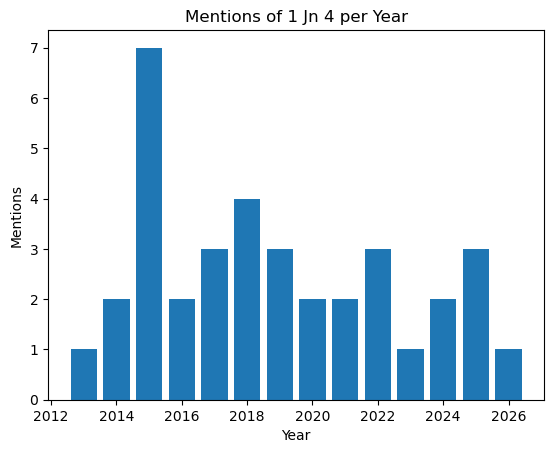

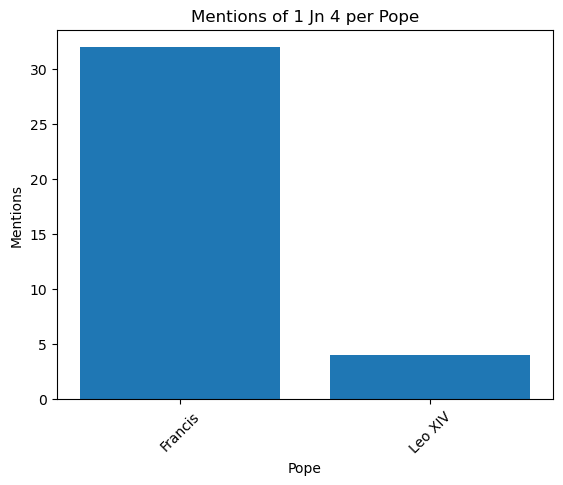

In [4]:
plt.bar(year_counts.keys(), year_counts.values())
plt.title("Mentions of 1 Jn 4 per Year")
plt.xlabel("Year")
plt.ylabel("Mentions")
plt.show()
plt.bar(pope_counts.keys(), pope_counts.values())
plt.title("Mentions of 1 Jn 4 per Pope")
plt.xlabel("Pope")
plt.ylabel("Mentions")
plt.xticks(rotation=45)
plt.show()